In [7]:
import os, sys
os.chdir('C:/Project(CSE_155)/retail-digital-twin')
sys.path.append('C:/Project(CSE_155)/retail-digital-twin')

import pandas as pd
from backend.models.engagement_predictor import EngagementPredictorV2

twins = pd.read_csv('datasets/processed/digital_twins.csv')
print(f"Loaded: {len(twins):,} profiles")
print(f"Columns: {twins.columns.tolist()}")

Loaded: 1,407,580 profiles
Columns: ['visitorid', 'total_addtocarts', 'total_purchases', 'total_views', 'engagement_score', 'total_events', 'view_to_cart_rate', 'cart_to_purchase_rate', 'view_to_purchase_rate', 'is_buyer', 'is_high_value', 'engagement_percentile', 'purchase_percentile', 'engagement_level', 'customer_segment', 'funnel_position', 'purchase_intent_score', 'clv_tier', 'roi_potential', 'behavior_type']


In [8]:
predictor = EngagementPredictorV2()
clean_df = predictor.build_clean_features(twins)
clean_df.to_csv('datasets/processed/digital_twins_clean.csv', index=False)
print(clean_df[predictor.feature_names + ['is_buyer']].head(10))

Building leakage-free features...
  Features built: 8 predictors
  All derived from: total_views + total_addtocarts only
   total_views  total_addtocarts  view_to_cart_rate  cart_rate_flag  \
0            3                 0                0.0               0   
1            1                 0                0.0               0   
2            8                 0                0.0               0   
3            1                 0                0.0               0   
4            1                 0                0.0               0   
5            1                 0                0.0               0   
6            5                 1               20.0               1   
7            3                 0                0.0               0   
8            1                 0                0.0               0   
9            1                 0                0.0               0   

   engagement_score_clean  total_events_clean  activity_ratio  \
0                       3       

In [9]:
predictor.prepare_data(clean_df)


Dataset: 1,407,580 customers
Buyers: 11,719 (0.83%)
Class weight ratio: 1:119

Train: 985,306 | Val: 211,137 | Test: 211,137
Train buyers: 8,203
Val buyers:   1,758
Test buyers:  1,758


In [10]:
baseline_f1 = predictor.evaluate_baseline(predictor.y_test)
print(f"\nBaseline F1: {baseline_f1:.4f}")
print("Every ML model must beat this to justify its complexity.")


=== HEURISTIC BASELINE ===
Rule: if addtocart > 0 → predict buyer
  Precision: 0.2822
  Recall:    0.9073
  F1 Score:  0.4305

Baseline F1: 0.4305
Every ML model must beat this to justify its complexity.


In [11]:
predictor.train_all_models()


Class weights: Non-buyer=0.50, Buyer=60.06

Training Logistic Regression...
  ✓ Done
Training Random Forest...
  ✓ Done
Training XGBoost...
  ✓ Done
Training Gradient Boosting...
  ✓ Done

✅ All 4 models trained


In [12]:
results = predictor.evaluate_all_models()


MODEL EVALUATION — TEST SET (never seen during training)

Optimal threshold for Logistic Regression: 0.96 (F1=0.4392)

Logistic Regression
---------------------------------------------
  Accuracy          : 0.9818
  Precision         : 0.2977
  Recall            : 0.8743
  F1 Score          : 0.4442
  ROC-AUC           : 0.9648
  Avg Precision     : 0.3452
  Threshold         : 0.9600000000000001

Optimal threshold for Random Forest: 0.97 (F1=0.4407)

Random Forest
---------------------------------------------
  Accuracy          : 0.9824
  Precision         : 0.304
  Recall            : 0.8618
  F1 Score          : 0.4494
  ROC-AUC           : 0.9732
  Avg Precision     : 0.3688
  Threshold         : 0.97

Optimal threshold for XGBoost: 0.97 (F1=0.4441)

XGBoost
---------------------------------------------
  Accuracy          : 0.9824
  Precision         : 0.3047
  Recall            : 0.8726
  F1 Score          : 0.4516
  ROC-AUC           : 0.974
  Avg Precision     : 0.3779
  Thre

In [13]:
print("\n=== FINAL MODEL COMPARISON ===\n")
print(predictor.get_comparison_table().to_string())


=== FINAL MODEL COMPARISON ===

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  Avg Precision  Threshold
Gradient Boosting      0.9824     0.3044  0.8709    0.4512   0.9740         0.3714       0.20
XGBoost                0.9824     0.3047  0.8726    0.4516   0.9740         0.3779       0.97
Random Forest          0.9824     0.3040  0.8618    0.4494   0.9732         0.3688       0.97
Logistic Regression    0.9818     0.2977  0.8743    0.4442   0.9648         0.3452       0.96


In [14]:
predictor.cross_validate_best_model()


=== 5-FOLD CROSS VALIDATION — XGBoost ===
  AUC per fold: [np.float64(0.9643), np.float64(0.9701), np.float64(0.9701), np.float64(0.9718), np.float64(0.9668)]
  Mean AUC:     0.9686
  Std Dev:      0.0027
  (Low std dev = stable model)


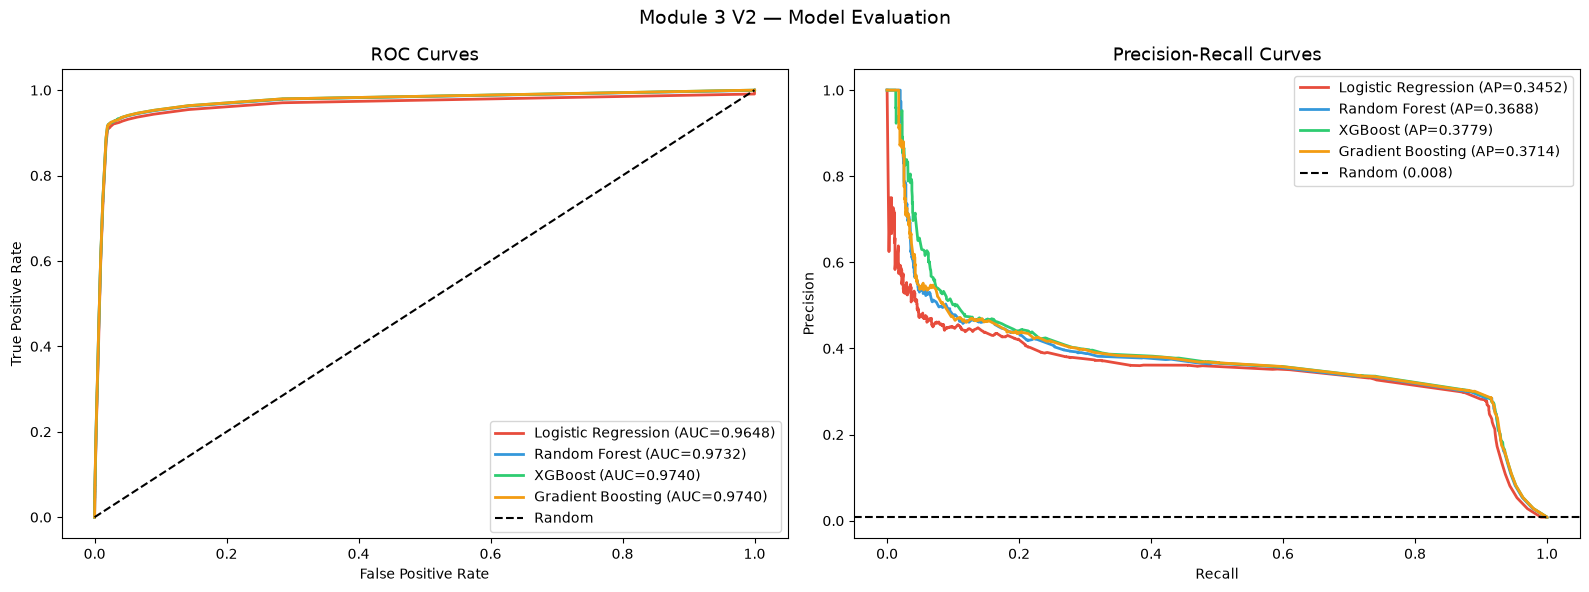

Saved: research/roc_pr_curves_v2.png


In [15]:
predictor.plot_roc_and_pr_curves()

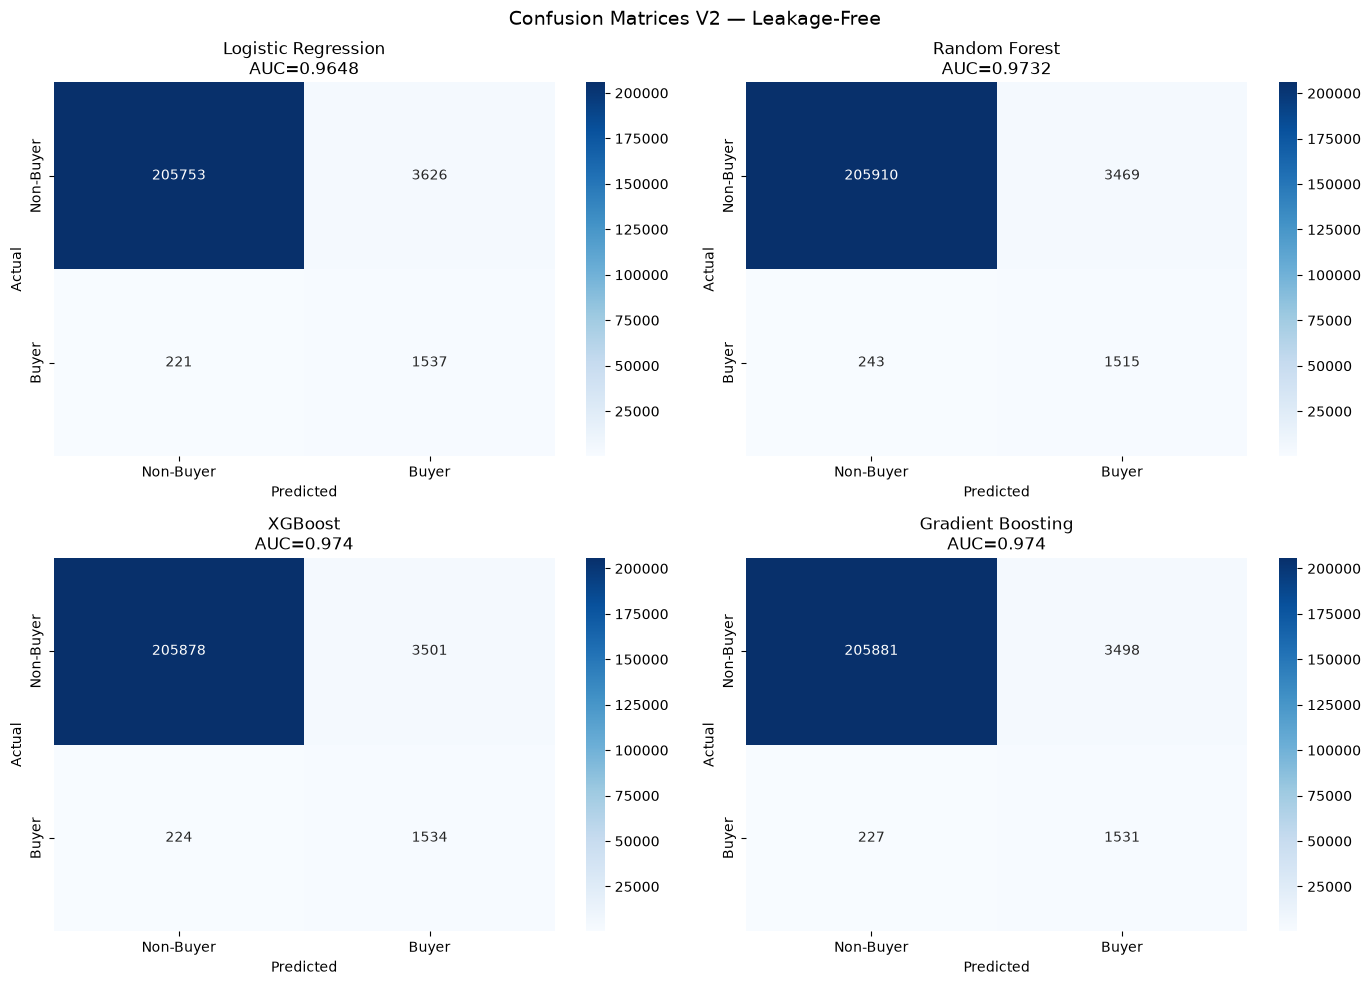

In [16]:
predictor.plot_confusion_matrices()

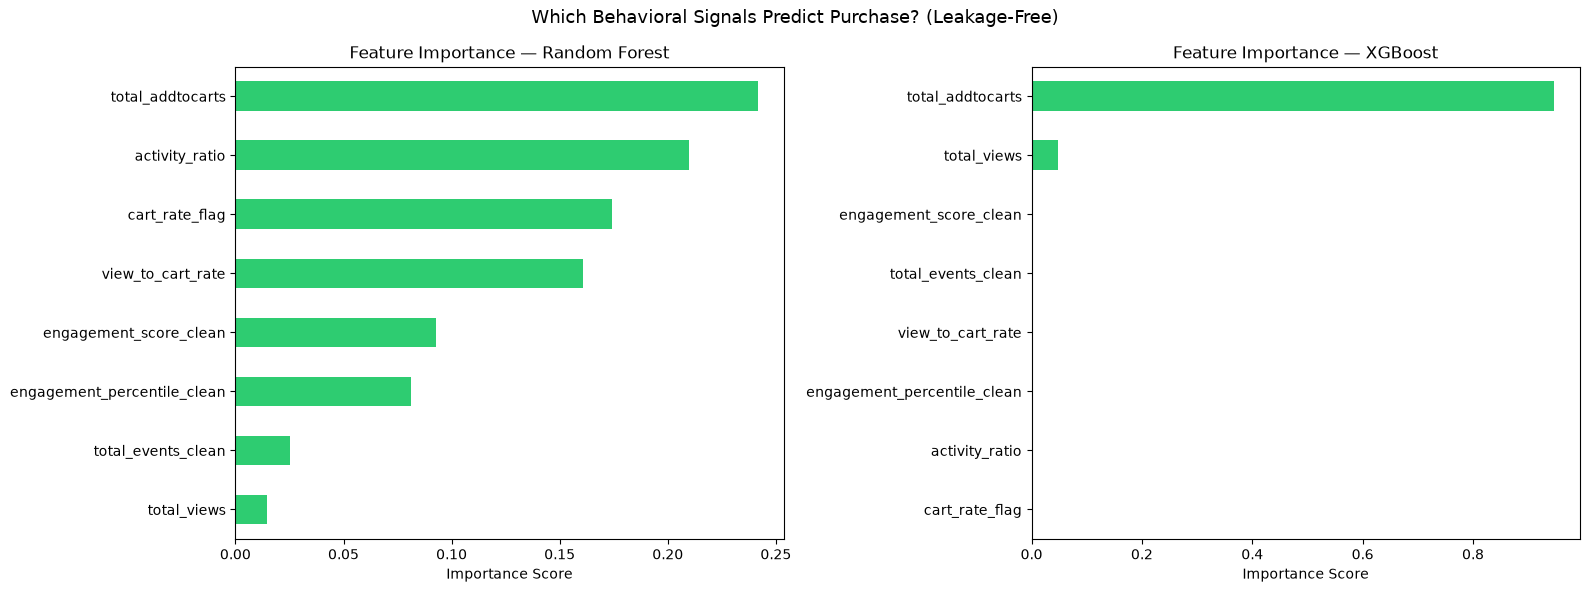

In [17]:
predictor.plot_feature_importance()

In [18]:
enriched = predictor.score_full_dataset(
    clean_df,
    'datasets/processed/digital_twins_with_predictions_v2.csv'
)

high = enriched[enriched['buy_probability'] >= 0.5]
non_buyers_likely = enriched[
    (enriched['is_buyer'] == 0) & (enriched['buy_probability'] >= 0.3)
]

print(f"\nCustomers with buy_probability >= 50%: {len(high):,}")
print(f"Non-buyers worth targeting: {len(non_buyers_likely):,}")
print(f"\nTop 10 non-buyers most likely to convert:")
print(
    enriched[enriched['is_buyer']==0]
    .nlargest(10, 'buy_probability')
    [['visitorid','total_views','total_addtocarts',
      'view_to_cart_rate','buy_probability']]
    .to_string(index=False)
)

Saved: datasets/processed/digital_twins_with_predictions_v2.csv
Predicted buyers: 33,614
Avg buy probability: 0.0987

Customers with buy_probability >= 50%: 42,595
Non-buyers worth targeting: 70,456

Top 10 non-buyers most likely to convert:
 visitorid  total_views  total_addtocarts  view_to_cart_rate  buy_probability
    719708          328                91              27.74           0.9997
   1032742          184                71              38.59           0.9997
   1109474          604                 8               1.32           0.9987
    371257          169                12               7.10           0.9965
   1145249          113                10               8.85           0.9965
   1380669          142                10               7.04           0.9964
    187778           66                11              16.67           0.9963
    398192          123                11               8.94           0.9963
    433298          119                11               